# Module 15: Advanced Interest Rate Exotics

This notebook verifies the mathematical correctness of our exotic interest rate models:
1. **LIBOR Market Model (LMM)**
2. **Constant Maturity Swaps (CMS)**
3. **Target Redemption Notes (TARN)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../src')
from exotics.lmm import LiborMarketModel, SABRForwardMarketModel
from exotics.cms import ConstantMaturitySwap
from exotics.tarn import TargetRedemptionNote

## 1. LIBOR Market Model (LMM) with Predictor-Corrector

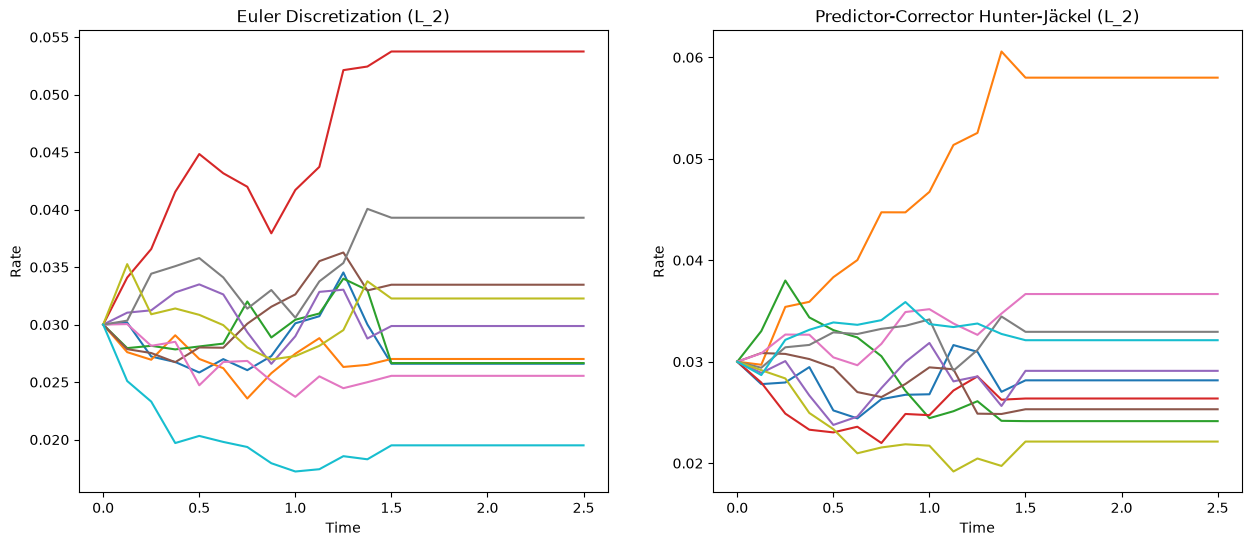

In [2]:
forward_rates = [0.02, 0.025, 0.03, 0.035, 0.04]
tenors = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
volatilities = [0.15, 0.18, 0.20, 0.22, 0.25]

# Create a simple correlation matrix (exponential decay)
corr = np.zeros((5, 5))
for i in range(5):
    for j in range(5):
        corr[i, j] = np.exp(-0.1 * abs(i - j))

lmm = LiborMarketModel(forward_rates, tenors, volatilities, corr)
paths_euler = lmm.simulate_spot_measure(dt=0.125, n_paths=1000, method='euler')
paths_pc = lmm.simulate_spot_measure(dt=0.125, n_paths=1000, method='pc')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for i in range(10):
    ax1.plot(np.linspace(0, 2.5, paths_euler.shape[1]), paths_euler[i, :, 2])
    ax2.plot(np.linspace(0, 2.5, paths_pc.shape[1]), paths_pc[i, :, 2])
ax1.set_title("Euler Discretization (L_2)")
ax2.set_title("Predictor-Corrector Hunter-Jäckel (L_2)")
for ax in (ax1, ax2):
    ax.set_xlabel("Time")
    ax.set_ylabel("Rate")
plt.show()

## 1b. Forward Market Model (FMM) and SABR-FMM

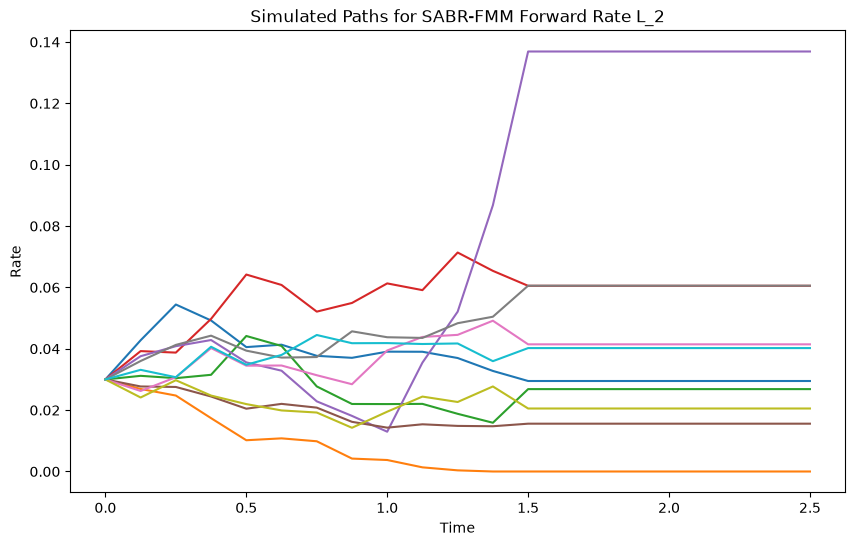

In [3]:
alpha = [0.1, 0.1, 0.1, 0.1, 0.1]
beta = [0.5, 0.5, 0.5, 0.5, 0.5]
rho = [-0.3, -0.3, -0.3, -0.3, -0.3]
nu = [0.4, 0.4, 0.4, 0.4, 0.4]

sabr_fmm = SABRForwardMarketModel(forward_rates, tenors, alpha, beta, rho, nu, corr)
rates, alphas = sabr_fmm.simulate_spot_measure(dt=0.125, n_paths=100)

plt.figure(figsize=(10, 6))
for i in range(10):
    plt.plot(np.linspace(0, 2.5, rates.shape[1]), rates[i, :, 2])
plt.title("Simulated Paths for SABR-FMM Forward Rate L_2")
plt.xlabel("Time")
plt.ylabel("Rate")
plt.show()

## 2. Constant Maturity Swaps (CMS)

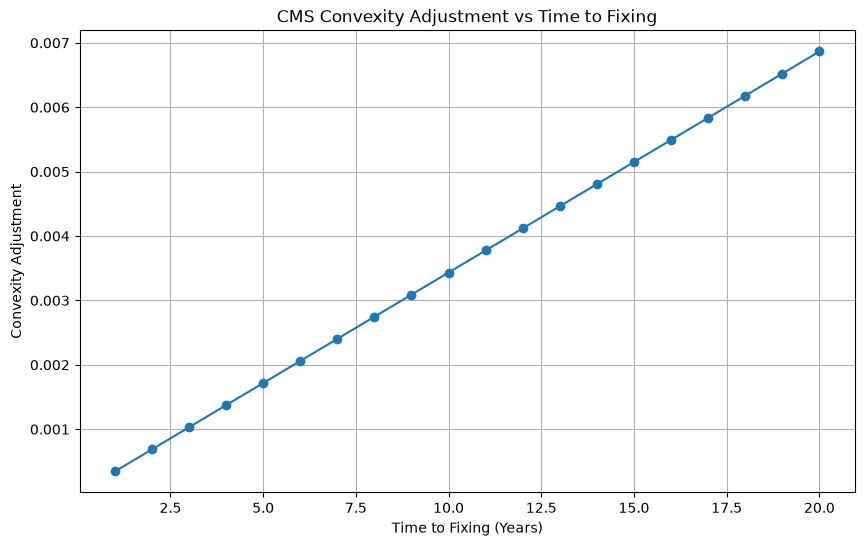

In [4]:
cms = ConstantMaturitySwap(
    forward_swap_rate=0.05, swap_tenor_years=10, payment_frequency=2, volatility=0.20
)
times_to_fixing = np.linspace(1, 20, 20)
adjustments = [cms.convexity_adjustment(t) for t in times_to_fixing]

plt.figure(figsize=(10, 6))
plt.plot(times_to_fixing, adjustments, marker="o")
plt.title("CMS Convexity Adjustment vs Time to Fixing")
plt.xlabel("Time to Fixing (Years)")
plt.ylabel("Convexity Adjustment")
plt.grid(True)
plt.show()

## 3. Target Redemption Notes (TARN)

In [5]:
# Simulate TARN pricing with random CMS rates
notional = 1_000_000
target_cap = 0.15  # 15% total

# Random CMS rates for paths
np.random.seed(42)
n_paths = 1000
n_periods = 10
simulated_cms = np.random.normal(loc=0.04, scale=0.01, size=(n_paths, n_periods))
simulated_cms = np.clip(simulated_cms, 0.0, None)


def coupon_rate_func(p, t_idx):
    # Coupon is max(CMS - 0.02, 0)
    return max(simulated_cms[p, t_idx] - 0.02, 0.0)


def funding_rate_func(_p, _t_idx):
    return 0.03  # constant discount


tarn = TargetRedemptionNote(notional, target_cap, coupon_rate_func, funding_rate_func)
price, stderr = tarn.price(
    n_paths=n_paths, payment_times=range(1, n_periods + 1), dt=1.0
)

print(f"TARN Price: {price:,.2f}")
print(f"Standard Error: {stderr:,.2f}")

TARN Price: 918,378.23
Standard Error: 1,020.82
